

** Analista d'experiència del client: 

- Quins aspectes (precisió de detalls, higiene, check-in o
comunicació) presenten diferències més grans entre els allotjaments millor i pitjor valorats en
l'avaluació general?

In [286]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [305]:
df = pd.read_csv("../../Data/clean_data 16-03-2026.csv", parse_dates=['insert_date','first_review_date','last_review_date'])

df.columns

pd.set_option('display.max_columns', 40)

# Selecciono solo las columnas que nos interesan para visualizar más fácil

df[['apartment_id',
    'room_type', 
    'price',
    'number_of_reviews',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month',
    'city']]

,apartment_id,room_type,price,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,city
0,11964,Private room,400.0,78,97.0,100.0,100.0,100.0,100.0,100.0,100.0,75.0,Malaga
1,21853,Private room,170.0,33,92.0,90.0,90.0,100.0,100.0,80.0,90.0,52.0,Madrid
2,32347,Entire home/apt,990.0,148,98.0,100.0,100.0,100.0,100.0,100.0,100.0,142.0,Sevilla
3,35379,Private room,400.0,292,94.0,100.0,90.0,100.0,100.0,100.0,90.0,306.0,Barcelona
4,35801,Private room,900.0,36,97.0,100.0,100.0,100.0,100.0,100.0,100.0,39.0,Girona
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7532,32392193,Private room,3000.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Barcelona
7533,32392774,Entire home/apt,2090.0,36,100.0,100.0,100.0,100.0,100.0,100.0,100.0,157.0,Sevilla
7534,32395123,Entire home/apt,930.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mallorca
7535,32407332,Private room,960.0,21,98.0,100.0,100.0,100.0,100.0,100.0,100.0,389.0,Barcelona


Medias generales de las variables de calificación de alojamientos

In [288]:
df[['review_scores_rating', 
    'review_scores_accuracy',
    'review_scores_cleanliness', 
    'review_scores_checkin',
    'review_scores_communication']].mean()

review_scores_rating           91.912140
review_scores_accuracy         94.549118
review_scores_cleanliness      93.091763
review_scores_checkin          96.277311
review_scores_communication    96.346702
dtype: float64

** Definir grupos usando percentiles.

- Top 25% → mejores alojamientos
- Bottom 25% → peores alojamientos

In [289]:
top = df[df["review_scores_rating"] >= df["review_scores_rating"].quantile(0.75)]
bottom = df[df["review_scores_rating"] <= df["review_scores_rating"].quantile(0.25)]

In [290]:
# Cálculo de medias
features = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication"
]

top_avg = top[features].mean()
bottom_avg = bottom[features].mean()

In [291]:
difference = (top_avg - bottom_avg).sort_values(ascending=False)

diff_df = pd.DataFrame({
    "Top listings": top_avg,
    "Bottom listings": bottom_avg,
    "Difference": difference
}).round(2)

print(diff_df)

                             Top listings  Bottom listings  Difference
review_scores_accuracy              99.10            85.90       13.20
review_scores_checkin               99.12            90.25        8.87
review_scores_cleanliness           98.34            84.30       14.03
review_scores_communication         99.27            90.12        9.15


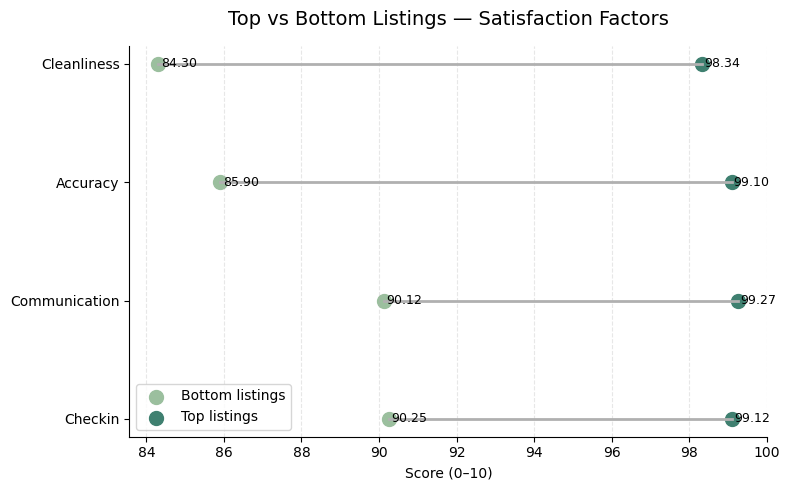

In [292]:

# 1. Crear grupos
top = df[df["review_scores_rating"] >= df["review_scores_rating"].quantile(0.75)]
bottom = df[df["review_scores_rating"] <= df["review_scores_rating"].quantile(0.25)]

# 2. Variables a comparar
features = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication"
]

# 3. Medias
top_avg = top[features].mean()
bottom_avg = bottom[features].mean()

# 4. DataFrame
dumbbell_df = pd.DataFrame({
    "Feature": features,
    "Top": top_avg.values,
    "Bottom": bottom_avg.values
})

# Limpiar nombres
dumbbell_df["Feature"] = dumbbell_df["Feature"].str.replace("review_scores_", "").str.capitalize()

# Ordenar por diferencia
dumbbell_df["diff"] = dumbbell_df["Top"] - dumbbell_df["Bottom"]
dumbbell_df = dumbbell_df.sort_values("diff")

# 5. Gráfico
plt.figure(figsize=(8,5))

# Líneas (dumbbell)
for i, row in dumbbell_df.iterrows():
    plt.plot(
        [row["Bottom"], row["Top"]],
        [row["Feature"], row["Feature"]],
        color="#b0b0b0",
        linewidth=2
    )

# Puntos
plt.scatter(
    dumbbell_df["Bottom"],
    dumbbell_df["Feature"],
    color="#9bbf9e",
    s=100,
    label="Bottom listings"
)

plt.scatter(
    dumbbell_df["Top"],
    dumbbell_df["Feature"],
    color="#3f8070",
    s=100,
    label="Top listings"
)

# Etiquetas valores
for i, row in dumbbell_df.iterrows():
    plt.text(row["Bottom"] + 1, row["Feature"], f"{row['Bottom']:.2f}", va="center", ha="right", fontsize=9)
    plt.text(row["Top"] + 0.05, row["Feature"], f"{row['Top']:.2f}", va="center", ha="left", fontsize=9)

plt.title("Top vs Bottom Listings — Satisfaction Factors", fontsize=14, pad=15)
plt.xlabel("Score (0–10)")
plt.ylabel("")

plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.3)

for spine in ["top","right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Observar distribución

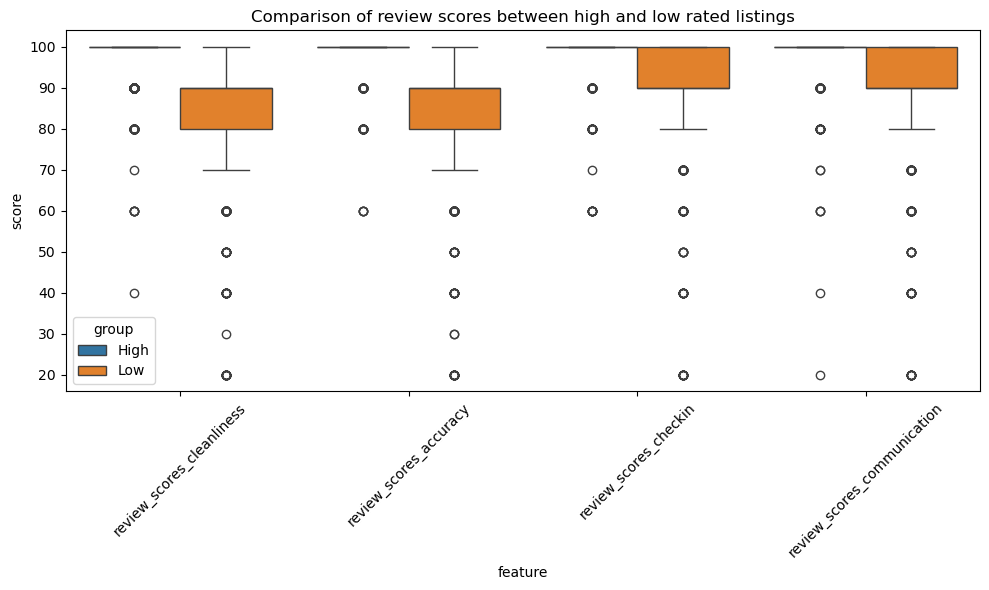

In [293]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    'review_scores_cleanliness', 
    'review_scores_accuracy',
    'review_scores_checkin', 
    'review_scores_communication'
]

df_plot = df.copy()

q_low = df["review_scores_rating"].quantile(0.25)
q_high = df["review_scores_rating"].quantile(0.75)

df_plot['group'] = 'Mid'
df_plot.loc[df_plot['review_scores_rating'] <= q_low, 'group'] = 'Low'
df_plot.loc[df_plot['review_scores_rating'] >= q_high, 'group'] = 'High'

df_melt = df_plot[df_plot['group'] != 'Mid'].melt(
    id_vars='group', 
    value_vars=features,
    var_name='feature',
    value_name='score'
)

plt.figure(figsize=(10,6))
sns.boxplot(data=df_melt, x='feature', y='score', hue='group')

plt.title("Comparison of review scores between high and low rated listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

los alojamientos buenos son casi todos perfectos en todas las caracteristicas (homogeneidad)

Los alojamientos bien valorados son muy homogéneos, mientras que los mal valorados presentan una gran variabilidad en sus puntuaciones (dispersion)

hay alojamientos con buena limpieza / accuracy que aun así tienen mala valoración general. (solapamiento)

--> Por lo tanto esto significa que altas puntuaciones en aspectos individuales tampoco no garantiza un promedio de puntuación alto.

Esto es para observar si hay alojamientos del cuartil inferior que a pesar de que tengan ratings al 100%, siguen teniendo un overall rating malo.

In [294]:
# La unica trampa de esto es que nos falta calidad_precio aqui (review_scores_value)

perfect_bot = bottom.loc[(bottom['review_scores_accuracy'] == 100) & (bottom['review_scores_cleanliness'] == 100) & (bottom['review_scores_checkin'] == 100) & (bottom['review_scores_communication'] == 100)]['apartment_id'].count()

almost_perfect_bot = bottom.loc[(bottom['review_scores_accuracy'] == 100) & (bottom['review_scores_cleanliness'] == 100)]['apartment_id'].count()

print('De los peores alojamientos, tienen todas las estadisticas perfectas:',perfect_bot, 'alojamientos' )
print('De los peores alojamientos, tienen accuracy y cleanliness perfectos:',almost_perfect_bot, 'alojamientos')

De los peores alojamientos, tienen todas las estadisticas perfectas: 49 alojamientos
De los peores alojamientos, tienen accuracy y cleanliness perfectos: 88 alojamientos


## Correlaciones

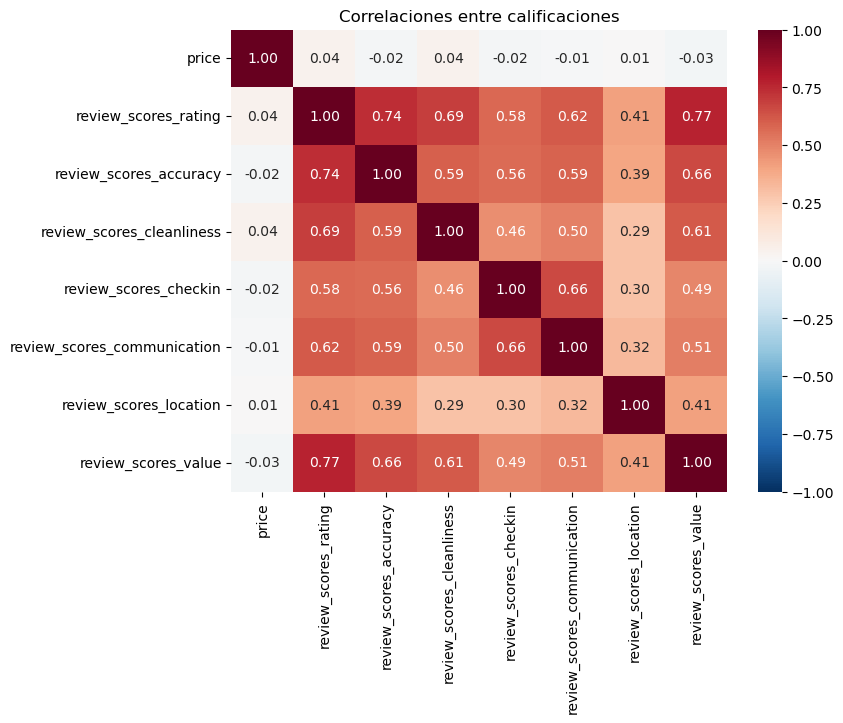

In [295]:
df_corr = df[['price','review_scores_rating', 'review_scores_accuracy','review_scores_cleanliness', 'review_scores_checkin','review_scores_communication', 'review_scores_location','review_scores_value']] # 'reviews_per_month','number_of_reviews'

plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr(), cmap= 'RdBu_r', annot=True, fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Correlaciones entre calificaciones")
plt.show()


Este gráfico es para observar las relaciones entre categorías de calificación. Todas ellas mantienen correlaciones, más o menos elevadas.

Qué correlaciones existen entre calificación general y calificaciones específicas?

Existe un efecto contagio? A veces, cuando un cliente se enfada por algun motivo, castiga el resto de categorías, y viceversa.

- Limpieza y accuracy son las variables más importantes para la calificación general (0.7)
- Communication y check-in van de la mano (correlación entre ellas)

- Price y review_scores no muestra correlación (0), con lo cual mayor precio no garantiza mayor rating ni menor rating. El precio y la calidad percibida no correlacionan.

*Insight y propuestas de negocio*

Obviando el precio y la ubicación, el éxito de StaySpain descansa sobre dos pilares: la higiene y la honestidad.

- La limpieza es un pilar fundamental. Un alojamiento puede estar lejos o ser sencillo, pero si está impecable, la nota general sube.
    - Programas de limpieza para garantizar o verificar estándares mínimos.
    - Anfitriones utilicen empresas de limpieza profesionales.

- El accuracy, más importante todavía. El Accuracy mide la brecha entre la expectativa (fotos/descripción) y la realidad. 
    - No debemos 'sobre-vender' los alojamientos en las fotos de la plataforma.
    - Sistema de verificación de inventario.

### Random Forest Regression

In [296]:
features = [ 
    'review_scores_cleanliness', 
    'review_scores_accuracy',
    'review_scores_checkin', 
    'review_scores_communication'
]

df_ml = df.dropna(subset=features + ['review_scores_rating'])

X = df_ml[features]
y = df_ml['review_scores_rating']

In [297]:
# Train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [298]:
rf = RandomForestRegressor(
    n_estimators=2000,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,2000
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [299]:
# 4. Extraer la importancia de las variables
importances = rf.feature_importances_
feature_names = [f.replace('review_scores_', '').capitalize() for f in features]
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)

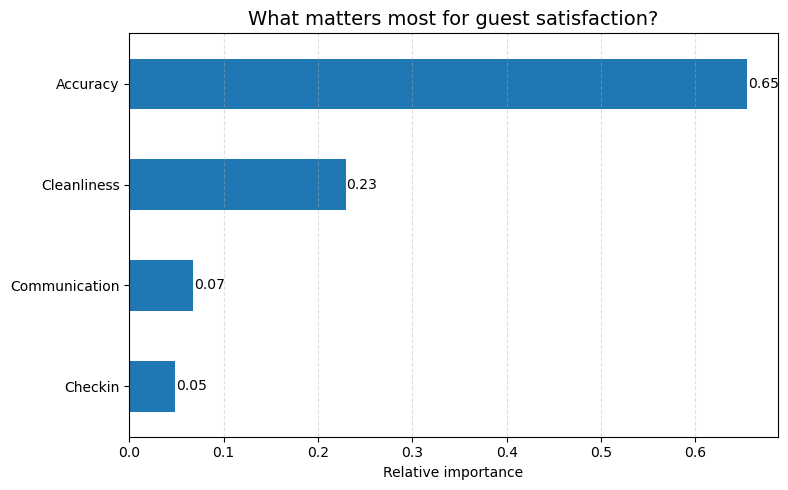

In [300]:
# 5. Visualización
plt.figure(figsize=(8, 5))

forest_importances.sort_values().plot(kind='barh')

plt.title("What matters most for guest satisfaction?", fontsize=14)
plt.xlabel("Relative importance")

for i, v in enumerate(forest_importances.sort_values()):
    plt.text(v + 0.001, i, f"{v:.2f}", va='center')

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Cleanliness and accuracy are both strongly related to overall rating, but they share a significant amount of information. The model prioritizes accuracy as the most efficient predictor.

Pero NO significa que accuracy sea más importante.

In [301]:
# Evaluación del modelo. 3.31 puntos de rating de error. El modelo explica el 55% de la variabilidad del rating (la mitad)

from sklearn.metrics import mean_absolute_error, r2_score

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.2f}")

MAE: 3.31
R2: 0.55


In [302]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

pd.Series(result.importances_mean, index=X.columns).sort_values()

review_scores_checkin          0.027798
review_scores_communication    0.052279
review_scores_cleanliness      0.234120
review_scores_accuracy         0.313055
dtype: float64

Both accuracy and cleanliness play a key role in explaining overall ratings, with accuracy showing a slightly stronger effect. However, the relatively close importance values suggest that both variables capture overlapping aspects of guest satisfaction.